In [13]:
# 셀 1: 기본 라이브러리 및 SHAP, Matplotlib 설정

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import shap

# ✅ 한글 폰트 설정 (Windows 기준: 맑은 고딕)
from matplotlib import font_manager, rc

font_path = r"C:\Windows\Fonts\malgun.ttf"  # 윈도우 기본 한글 폰트
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)

# ✅ 마이너스 깨짐 방지
matplotlib.rcParams["axes.unicode_minus"] = False

print(f"사용 폰트: {font_name}")


사용 폰트: Malgun Gothic


In [17]:
# 셀 2: 경로 설정 + 파일 경로 기반 강제 import (trust_model / pipeline 둘 다 지원)

import sys
import os
from pathlib import Path
import importlib.util

# 1) 프로젝트 루트 절대 경로 (네 PC 기준)
PROJECT_ROOT = Path(r"C:\dev\study\eunjeong\SKN18-FINAL-1TEAM")

# 2) trust_model 및 pipeline 폴더 경로
TRUST_DIR = PROJECT_ROOT / "apps" / "reco" / "models" / "trust_model"
PIPELINE_DIR = TRUST_DIR / "pipeline"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRUST_DIR:", TRUST_DIR)
print("PIPELINE_DIR:", PIPELINE_DIR)

# 데이터 & 모델 경로
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "seoul_broker_merged.csv"
MODEL_DIR = TRUST_DIR / "models"

print("DATA_PATH:", DATA_PATH)
print("MODEL_DIR:", MODEL_DIR)

# 디버그용: 폴더 안 파일들 출력
if TRUST_DIR.exists():
    print("\\n[trust_model 폴더 파일]")
    print(os.listdir(TRUST_DIR))
if PIPELINE_DIR.exists():
    print("\\n[pipeline 폴더 파일]")
    print(os.listdir(PIPELINE_DIR))

# === 헬퍼: 지정한 경로에서 모듈 강제 로드 ===
def load_module_from_path(mod_name: str, file_path: Path):
    if not file_path.exists():
        raise FileNotFoundError(f"모듈 파일을 찾을 수 없습니다: {file_path}")
    spec = importlib.util.spec_from_file_location(mod_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

# 3) _02_feature_engineering.py에서 add_features 가져오기
#    - trust_model 바로 아래 or pipeline 폴더 둘 다 탐색
fe_candidates = [
    TRUST_DIR / "_02_feature_engineering.py",
    PIPELINE_DIR / "_02_feature_engineering.py",
]

fe_path = None
for p in fe_candidates:
    if p.exists():
        fe_path = p
        break

if fe_path is None:
    raise FileNotFoundError(
        "⚠️ _02_feature_engineering.py 를 찾을 수 없습니다. "
        f"다음 위치를 확인해 주세요:\\n- {fe_candidates[0]}\\n- {fe_candidates[1]}"
    )

print(f"✅ _02_feature_engineering.py 사용 경로: {fe_path}")
fe_module = load_module_from_path("_02_feature_engineering", fe_path)
add_features = fe_module.add_features

# 4) _0A_create_target.py 있으면 create_binary_target 가져오기
target_candidates = [
    TRUST_DIR / "_0A_create_target.py",
    PIPELINE_DIR / "_0A_create_target.py",
]

target_path = None
for p in target_candidates:
    if p.exists():
        target_path = p
        break

if target_path is not None:
    print(f"✅ _0A_create_target.py 사용 경로: {target_path}")
    target_module = load_module_from_path("_0A_create_target", target_path)
    create_binary_target = target_module.create_binary_target
    HAS_BINARY_TARGET = True
else:
    HAS_BINARY_TARGET = False
    print("⚠️ _0A_create_target.py 를 찾지 못했습니다. (이진 타겟 생성 없이 진행)")

PROJECT_ROOT: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM
TRUST_DIR: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\apps\reco\models\trust_model
PIPELINE_DIR: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\apps\reco\models\trust_model\pipeline
DATA_PATH: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\data\raw\seoul_broker_merged.csv
MODEL_DIR: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\apps\reco\models\trust_model\models
\n[trust_model 폴더 파일]
['image-1.png', 'image.png', 'models', 'pipeline', 'preprocessing', 'README.md', 'README_binary.md', 'results', 'run_all.py', 'run_all_binary.py', 'shap_analysis.ipynb', 'shap_analysis.py', '__init__.py', '__pycache__']
\n[pipeline 폴더 파일]
['_00_load_data.py', '_01_create_target.py', '_02_feature_engineering.py', '_03_train_model.py', '_0A_create_target.py', '_0B_train_model.py', '__init__.py', '__pycache__']
✅ _02_feature_engineering.py 사용 경로: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\apps\reco\models\trust_model\pipeline\_02_feature_engineering.py
✅ _0A_create_target.py 사용 경로

In [18]:
# 셀 3: 데이터 준비 함수

def load_raw_data() -> pd.DataFrame:
    """원본 CSV 로드"""
    print(f"📂 CSV 로드: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print("   - 행 개수:", len(df))
    return df


def prepare_feature_data() -> pd.DataFrame:
    """
    SHAP 계산용 데이터 준비:
    - 원본 CSV 로드
    - 날짜 컬럼 dtype 변환
    - 보증보험유효 생성
    - (선택) 이진 타겟 생성
    - add_features(df)로 17개 피처 생성
    """
    df = load_raw_data().copy()

    # 1) 날짜 컬럼을 datetime으로 변환
    date_cols = ["registDe", "estbsBeginDe", "estbsEndDe", "lastUpdtDt"]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # 2) 보증보험유효 생성 (보증보험 만료일 >= 오늘 → 1)
    if "estbsEndDe" in df.columns:
        today = pd.Timestamp.today().normalize()
        df["보증보험유효"] = (df["estbsEndDe"] >= today).astype(int)
    else:
        df["보증보험유효"] = 0

    # 3) (선택) 이진 타겟 생성 함수가 있으면 태워줌
    if HAS_BINARY_TARGET:
        try:
            df = create_binary_target(df)
        except Exception as e:
            print("⚠️ create_binary_target 실행 중 오류 (무시하고 진행):", e)

    # 4) 피처 엔지니어링
    df = add_features(df)
    print("   - 피처 엔지니어링 완료, 컬럼 수:", len(df.columns))
    return df


# 실제로 한 번 만들어서 확인
df_features = prepare_feature_data()
df_features.head()

📂 CSV 로드: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\data\raw\seoul_broker_merged.csv
   - 행 개수: 1312

📊 [2단계] 이진 분류 타겟 생성 (2등급)
   ✅ 분류 타겟 생성 완료
   - 타겟1: trust_target (A/B)
   - 타겟2: trust_binary (0/1)
   - 기준: 거래성사율 90.00% 이상 = A / 1

   등급 분포:
trust_target
A    815
B    497
Name: count, dtype: int64

   이진 타겟 분포:
trust_binary
1 (고수/A)    815
0 (신입/B)    497
Name: count, dtype: int64

   거래성사율 통계:
   - 평균: 77.84%
   - 범위: 0.00% ~ 100.00%
   - A등급: 90.2% ~ 100.0% (n=815)
   - B등급: 0.0% ~ 90.0% (n=497)

   ✅ Feature에서 거래완료 정보 제외 필요

🔧 [3단계] 피처 엔지니어링 (개선 버전 - 17개 피처)
   ✅ 시간 피처 6개 (영업일수, 영업년수, 등록일_년, 등록일_월, 계절, 보증보험_남은일수)
   ✅ 지역 피처 4개 (지역중개사수, 지역내_등록매물_순위, 지역_평균영업년수, 지역_매물밀도)
   ✅ 사무소 정보 피처 1개 (사무소_인원수)
   ✅ 파생 피처 4개 (매물_규모_지수, 지역_경쟁_강도, 영업년수_매물_상호작용, 1인당_등록매물수)

   📊 총 17개 피처 준비 완료 (10개 → 17개)
   ✅ 거래완료 정보 제외 (Target과 독립적)
   - 피처 엔지니어링 완료, 컬럼 수: 39


,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,...,보증보험_남은일수,지역중개사수,지역내_등록매물_순위,지역_평균영업년수,지역_매물밀도,사무소_인원수,매물_규모_지수,지역_경쟁_강도,영업년수_매물_상호작용,1인당_등록매물수
0,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
1,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
2,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
3,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
4,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.708451,2.737859,14.690141,1,2.833213,0.045070,13.911078,15.999984


In [21]:
# 1) 프로젝트 루트 & 원본 데이터 경로
PROJECT_ROOT = Path(r"C:\dev\study\eunjeong\SKN18-FINAL-1TEAM")
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "seoul_broker_merged.csv"

print("DATA_PATH:", DATA_PATH)

# 2) 원본 데이터 로드
df_raw = pd.read_csv(DATA_PATH)

# 3) (있으면) 이진 타겟 생성
try:
    df_raw = create_binary_target(df_raw)
except NameError:
    # create_binary_target 안 불러온 경우
    pass
except Exception as e:
    print("⚠️ create_binary_target 실행 중 오류 (무시하고 진행):", e)

# 4) 피처 엔지니어링
df_features = add_features(df_raw.copy())

print("df_features shape:", df_features.shape)
df_features.head()


DATA_PATH: C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\data\raw\seoul_broker_merged.csv

📊 [2단계] 이진 분류 타겟 생성 (2등급)
   ✅ 분류 타겟 생성 완료
   - 타겟1: trust_target (A/B)
   - 타겟2: trust_binary (0/1)
   - 기준: 거래성사율 90.00% 이상 = A / 1

   등급 분포:
trust_target
A    815
B    497
Name: count, dtype: int64

   이진 타겟 분포:
trust_binary
1 (고수/A)    815
0 (신입/B)    497
Name: count, dtype: int64

   거래성사율 통계:
   - 평균: 77.84%
   - 범위: 0.00% ~ 100.00%
   - A등급: 90.2% ~ 100.0% (n=815)
   - B등급: 0.0% ~ 90.0% (n=497)

   ✅ Feature에서 거래완료 정보 제외 필요

🔧 [3단계] 피처 엔지니어링 (개선 버전 - 17개 피처)
   ✅ 시간 피처 6개 (영업일수, 영업년수, 등록일_년, 등록일_월, 계절, 보증보험_남은일수)
   ✅ 지역 피처 4개 (지역중개사수, 지역내_등록매물_순위, 지역_평균영업년수, 지역_매물밀도)
   ✅ 사무소 정보 피처 1개 (사무소_인원수)
   ✅ 파생 피처 4개 (매물_규모_지수, 지역_경쟁_강도, 영업년수_매물_상호작용, 1인당_등록매물수)

   📊 총 17개 피처 준비 완료 (10개 → 17개)
   ✅ 거래완료 정보 제외 (Target과 독립적)
df_features shape: (1312, 39)


,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,...,보증보험_남은일수,지역중개사수,지역내_등록매물_순위,지역_평균영업년수,지역_매물밀도,사무소_인원수,매물_규모_지수,지역_경쟁_강도,영업년수_매물_상호작용,1인당_등록매물수
0,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
1,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
2,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
3,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.739437,2.737859,14.690141,1,2.890372,0.047887,14.191725,16.999983
4,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,...,30,355,0.708451,2.737859,14.690141,1,2.833213,0.045070,13.911078,15.999984


📦 이진분류 모델 로드: models\voting_ensemble_binary.pkl
   - 사용 피처 수: 17
   - 메타데이터: {'model_type': 'voting_binary_classification', 'base_models': ['RandomForest', 'GradientBoosting', 'ExtraTrees', 'XGBoost'], 'voting_type': 'soft', 'weights': [2, 1, 1, 2], 'test_accuracy': 0.935361216730038, 'train_accuracy': 0.994280266920877, 'overfit_gap': 0.058919050190838984, 'num_classes': 2, 'num_features': 17, 'classes': [0, 1], 'positive_class': 1, 'xgboost_included': True}
   - SHAP 계산용 샘플: 300/1312
🌳 SHAP 기준 모델: XGBoost (binary)


c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DummyCla

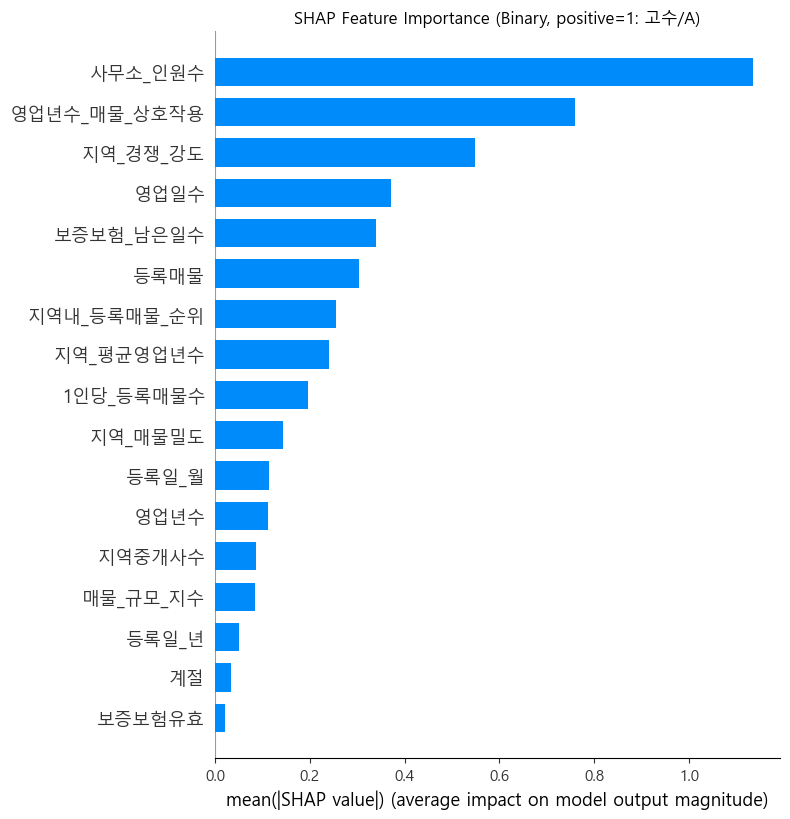

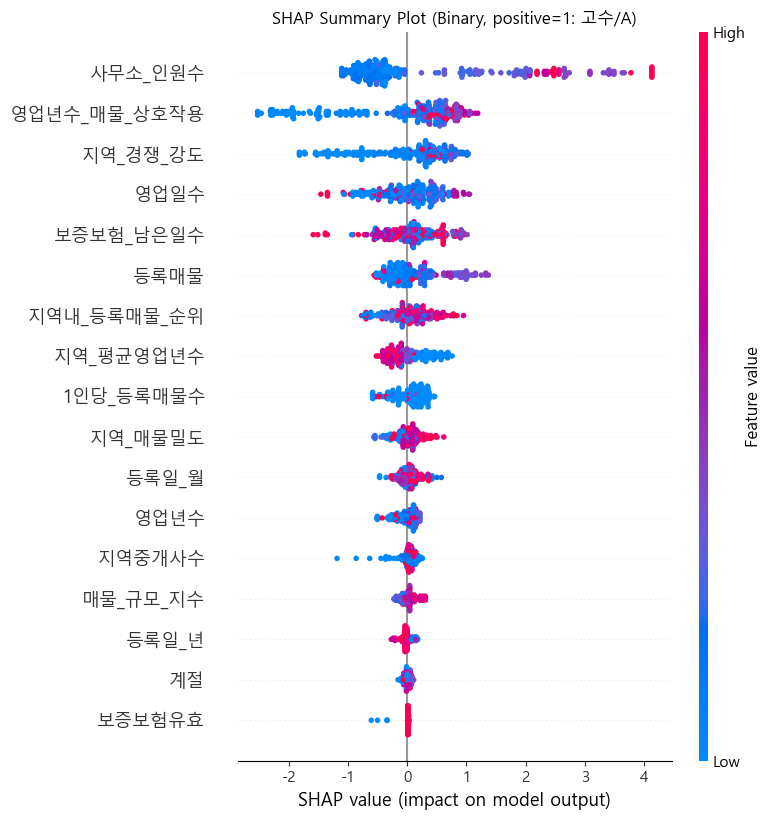

In [26]:
# 셀 4: 이진분류 모델 로드 및 SHAP 계산

import pickle
import shap
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost as xgb


def load_binary_model():
    """voting_ensemble_binary.pkl 로드"""
    model_path = MODEL_DIR / "voting_ensemble_binary.pkl"
    if not model_path.exists():
        raise FileNotFoundError(f"모델 파일이 없습니다: {model_path}")

    print(f"📦 이진분류 모델 로드: {model_path}")
    with open(model_path, "rb") as f:
        model_package = pickle.load(f)

    ensemble = model_package["ensemble"]
    scaler = model_package["scaler"]
    features = model_package["features"]
    metadata = model_package.get("metadata", {})

    print("   - 사용 피처 수:", len(features))
    print("   - 메타데이터:", metadata)
    return ensemble, scaler, features, metadata


def shap_binary(sample_size: int = 300, positive_class: int = 1):
    """
    이진분류(voting_ensemble_binary) 모델에 대해 SHAP 계산 & 시각화.

    positive_class:
        1 = 고수/A 클래스에 대한 SHAP 값.
    """
    ensemble, scaler, features, metadata = load_binary_model()

    df = df_features.copy()

    # 누락 피처가 있으면 0으로 채워서 맞춰줌 (방어코드)
    missing = [col for col in features if col not in df.columns]
    if missing:
        print("⚠️ 누락 피처:", missing, "→ 0으로 채워서 사용")
        for col in missing:
            df[col] = 0

    X = df[features]
    X_s = scaler.transform(X)

    # 샘플링
    n = len(X_s)
    if sample_size is not None and sample_size < n:
        idx = np.random.choice(n, size=sample_size, replace=False)
        X_sample = X_s[idx]
        print(f"   - SHAP 계산용 샘플: {sample_size}/{n}")
    else:
        X_sample = X_s
        print(f"   - SHAP 계산용 샘플: 전체 {n}개 사용")

    X_df_sample = pd.DataFrame(X_sample, columns=features)

    # VotingClassifier에서 XGBoost 또는 RF 기반 모델 하나 선택
    if hasattr(ensemble, "named_estimators_"):
        estimators = ensemble.named_estimators_
    else:
        raise RuntimeError("VotingClassifier에 named_estimators_ 속성이 없습니다.")

    if "xgb" in estimators:
        base_model = estimators["xgb"]
        base_name = "XGBoost"
    elif "rf" in estimators:
        base_model = estimators["rf"]
        base_name = "RandomForest"
    else:
        name0, base_model = list(estimators.items())[0]
        base_name = name0

    print(f"🌳 SHAP 기준 모델: {base_name} (binary)")

    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_sample)

    # 이진 분류일 때 shap_values 형식 처리
    if isinstance(shap_values, list):
        shap_bin = shap_values[positive_class]
    else:
        shap_bin = shap_values

    # 1) Feature Importance (bar)
    plt.figure(figsize=(12, 5))
    shap.summary_plot(
        shap_bin,
        X_df_sample,
        plot_type="bar",
        show=False,
    )
    plt.title("SHAP Feature Importance (Binary, positive=1: 고수/A)")
    plt.tight_layout()
    plt.show()

    # 2) Summary Plot (beeswarm)
    plt.figure(figsize=(12, 5))
    shap.summary_plot(
        shap_bin,
        X_df_sample,
        show=False,
    )
    plt.title("SHAP Summary Plot (Binary, positive=1: 고수/A)")
    plt.tight_layout()
    plt.show()


# 실제 실행 예시
shap_binary(sample_size=300, positive_class=1)
